# NFL player trajectory lab
## 00 · Project readiness

**Question:** Can we reproduce the environment, validate the data contract, score trajectories correctly, and recover completed work?

**Phase:** foundation. This notebook demonstrates the pipeline on synthetic motion. It does not claim an NFL benchmark score or a trained model. Run the real-data download and audit commands in `START_HERE.md` to populate the data summary below.

The problem is to predict future **x/y coordinates while the pass is in the air**. Whole games remain together in validation. GPU training starts in a later phase.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from nfl_trajectory.motion import KEYS, constant_velocity, trajectory_metrics
from nfl_trajectory.report import demo, synthetic_play
from nfl_trajectory.runtime import Run

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/nfl_trajectory").is_dir())
print(f"Python {sys.version.split()[0]} | Phase 0 | CPU")

Python 3.11.15 | Phase 0 | CPU


### 1 · Check the scoring definition

The official metric is **coordinate RMSE**, in yards:

$$\mathrm{RMSE}=\sqrt{\frac{1}{2N}\sum_i[(x_i-\hat{x}_i)^2+(y_i-\hat{y}_i)^2]}.$$

ADE measures typical Euclidean distance; FDE measures Euclidean distance at each player's last forecast frame. We report both frame and trajectory weighting for ADE, because longer forecasts otherwise contribute more rows. A 3-yard x error and 4-yard y error gives **RMSE = √12.5**, while Euclidean distance is **5 yards**.

In [2]:
observed, actual = synthetic_play()
predicted = constant_velocity(observed, actual[KEYS])
metrics = trajectory_metrics(actual, predicted)
display(pd.DataFrame([{"metric": key, "yards": value} for key, value in metrics.items()]).round(4))
print("Data: synthetic demonstration only. These are not NFL validation results.")

Data: synthetic demonstration only. These are not NFL validation results.


,metric,yards
0,coordinate_rmse_yards,1.1909
1,ade_frame_weighted_yards,1.2703
2,ade_trajectory_weighted_yards,1.2703
3,fde_trajectory_weighted_yards,3.5410
4,p95_displacement_yards,3.3315
5,coordinate_mae_yards,0.8969


### 2 · Inspect the trajectories

The constant-velocity reference uses the last two observed frames. Its future path stays straight while these synthetic players turn. The gap is an example of the behavior a learned model must improve.

Output frame **1** means **0.1 seconds after the final observed frame**, even if the last input frame has a much larger number. We do not subtract the last input frame number from the output clock.

{"timestamp": "2026-09-07T05:05:16.223+00:00", "run_id": "20260907T050516Z-caf25065", "event": "started", "elapsed_seconds": 0.0, "command": "notebook_demo"}
{"timestamp": "2026-09-07T05:05:16.230+00:00", "run_id": "20260907T050516Z-caf25065", "event": "stage_reused", "elapsed_seconds": 0.006, "stage": "demo", "original_elapsed_seconds": 0.23}
{"timestamp": "2026-09-07T05:05:16.230+00:00", "run_id": "20260907T050516Z-caf25065", "event": "demo_ready", "elapsed_seconds": 0.007, "report": "artifacts/demo/trajectory.html", "metrics": {"coordinate_rmse_yards": 1.1908954719033915, "ade_frame_weighted_yards": 1.2703212534123824, "ade_trajectory_weighted_yards": 1.2703212534123822, "fde_trajectory_weighted_yards": 3.5409651663062913, "p95_displacement_yards": 3.331548399113385, "coordinate_mae_yards": 0.896875}}
{"timestamp": "2026-09-07T05:05:16.230+00:00", "run_id": "20260907T050516Z-caf25065", "event": "completed", "elapsed_seconds": 0.007, "error_type": null}
Interactive offline report: ar

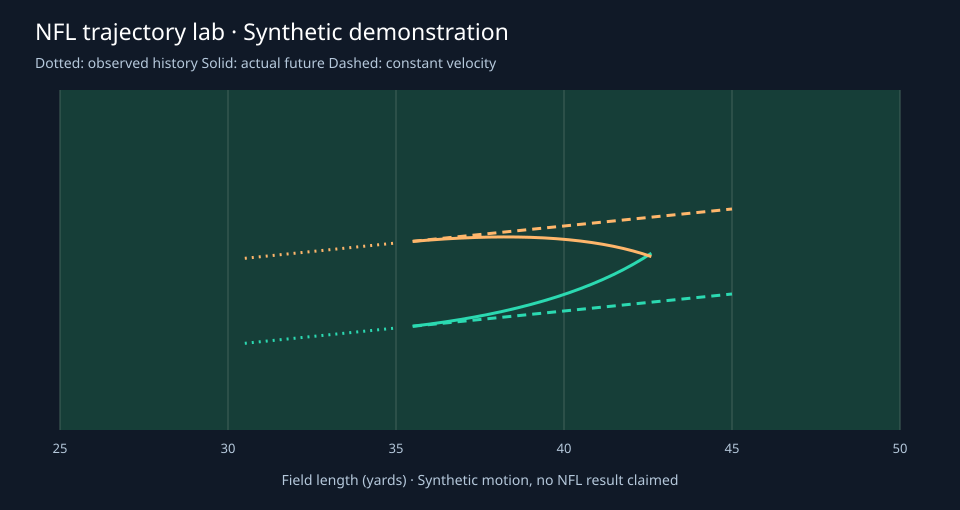

In [3]:
with Run(ROOT, "notebook_demo") as run:
    demo(ROOT, run)
from IPython.display import SVG

svg_path = ROOT / "artifacts/demo/trajectory.svg"
if svg_path.exists():
    display(SVG(filename=str(svg_path)))
print("Interactive offline report: artifacts/demo/trajectory.html")

### 3 · Inspect actual NFL readiness

This section becomes populated after `nfl download` and `nfl audit`. The audit reads one weekly pair at a time, validates unique player/frame keys and forecast horizons, then writes a proposed temporal split. The actual data remains outside Git.

In [4]:
audit_path = ROOT / "artifacts/audit_summary.json"
if audit_path.exists():
    audit = json.loads(audit_path.read_text())
    display(Markdown(f"**Actual data audit: {audit['status']}**"))
    display(pd.DataFrame(audit["pairs"]).drop(columns="games"))
    display(
        pd.read_csv(ROOT / "artifacts/game_splits.csv")
        .groupby("split")
        .agg(
            games=("game_id", "count"),
            first_date=("game_date", "min"),
            last_date=("game_date", "max"),
        )
    )
else:
    display(Markdown("**Real NFL audit: not run.** Follow Steps 4–5 in START_HERE.md."))

**Real NFL audit: not run.** Follow Steps 4–5 in START_HERE.md.

### 4 · Know what can be used at prediction time

| Information | Use |
| --- | --- |
| Pre-throw player positions, motion, and roles | Inputs |
| Ball landing coordinates and forecast horizon | Supplied by the organizer; allowed competition inputs |
| Actual post-throw player positions | Targets only |
| Post-play outcome or statistics | Excluded from features unless availability is established |
| Future games | Validation/holdout only; never used to fit earlier-game features |

The landing location is supplied by this benchmark. A deployment that does not know it would require a different model and separate evaluation.

### 5 · Next decision

After the real-data audit and backup succeed, Phase 1 will animate actual plays, review season/week coverage, freeze the split, and measure stationary, velocity, and acceleration references. Tree residual models and interaction-aware PyTorch models follow only after these baselines are established.

**Evidence to retain:** source commit, dependency lock, data hashes, split manifest, metric tables, plots, logs, and S3 snapshot identifier. Every future training run must have a tested resume path before substantial compute is launched.